In [ ]:
# ==============================================
# BOOT & UTILITÁRIOS
# ==============================================
import sqlite3, math, random, time, statistics
import pandas as pd

# -------- Haversine: distância geodésica em metros (WGS84) ----------
# (Haversine = fórmula para distância de arco entre dois pontos de latitude/longitude)
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0  # raio médio da Terra em metros
    phi1 = math.radians(lat1); phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1); dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2*R*math.asin(math.sqrt(a))

# Percentis (p50/p95) — p.ex. p95 = percentil 95 de latência
def pct(values, p):
    values = sorted(values)
    k = (len(values)-1) * (p/100.0)
    f = math.floor(k); c = math.ceil(k)
    if f == c: return values[int(k)]
    return values[f] + (values[c] - values[f]) * (k - f)

# Temporizador simples
class Tictoc:
    def __enter__(self): self.t0=time.perf_counter(); return self
    def __exit__(self, *exc): self.dt = (time.perf_counter()-self.t0)*1000  # ms

# Conexão SQLite (Structured Query Language + mecanismo relacional embarcado)
# Ativa modo "WAL" (Write-Ahead Logging) para melhor concorrência leitor/escritor
conn = sqlite3.connect(":memory:")
cur  = conn.cursor()
cur.execute("PRAGMA journal_mode=WAL;")
cur.execute("PRAGMA synchronous=NORMAL;")

# Registra UDF (User-Defined Function) 'haversine_m' no SQLite
conn.create_function("haversine_m", 4, haversine_m)

# Verifica suporte a R-Tree (árvore de regiões para índice geo-espacial)
# Muitos builds do SQLite já vêm com RTREE habilitado; se falhar, cairemos em 'fallback'
supports_rtree = True
try:
    cur.execute("CREATE VIRTUAL TABLE IF NOT EXISTS _rtree_probe USING rtree(id, minX, maxX, minY, maxY)")
    cur.execute("DROP TABLE _rtree_probe")
except sqlite3.OperationalError:
    supports_rtree = False

print("Journal:", cur.execute("PRAGMA journal_mode;").fetchone()[0])
print("R-Tree habilitado?", supports_rtree)

Journal: memory
R-Tree habilitado? True


In [ ]:
# ==============================================
# ESQUEMA v1 + CARGA SINTÉTICA
# ==============================================
# Tabelas principais:
# - parcel: encomendas com ponto geográfico (lat/lon) e metadados de operação
cur.executescript("""
DROP TABLE IF EXISTS parcel;

CREATE TABLE parcel (
  id            INTEGER PRIMARY KEY AUTOINCREMENT,
  customer_name TEXT    NOT NULL,
  status        TEXT    NOT NULL,         -- p.ex. 'pending', 'delivered', 'on_route'
  last_modified INTEGER NOT NULL,         -- epoch (segundos)
  lat           REAL    NOT NULL,
  lon           REAL    NOT NULL
);

-- Índice B-tree (Balanced Tree) auxiliar para filtros operacionais por status/data
CREATE INDEX idx_parcel_status_date ON parcel(status, last_modified);
""")

# Gera N pontos em torno de um centro (ex.: São Paulo – coordenadas aproximadas)
N = 120_000
center_lat, center_lon = -23.5505, -46.6333

def jitter_coord(lat, lon, radius_m=6000):
    # Desloca ponto até ~radius_m com ruído uniforme — aproximação cartesiana simples
    # 1 grau de latitude ≈ 111_320 m; 1 grau de longitude ≈ 111_320 * cos(latitude)
    dlat = (random.random()-0.5) * 2 * (radius_m/111_320.0)
    dlon = (random.random()-0.5) * 2 * (radius_m/(111_320.0*math.cos(math.radians(lat))))
    return lat + dlat, lon + dlon

statuses = ["pending","on_route","delivered"]

with conn:
    for _ in range(N):
        lat, lon = jitter_coord(center_lat, center_lon, radius_m=10_000)
        nm  = f"Cliente {_%10000:05d}"
        st  = random.choice(statuses)
        tss = int(time.time()) - random.randint(0, 60*60*24*30)  # último mês
        cur.execute("INSERT INTO parcel(customer_name,status,last_modified,lat,lon) VALUES (?,?,?,?,?)",
                    (nm, st, tss, lat, lon))

# Estatísticas para o Otimizador de Custo (CBO, Cost-Based Optimizer)
cur.execute("ANALYZE;")
conn.commit()

# Amostra de dados
df = pd.read_sql_query("SELECT id, customer_name, status, lat, lon FROM parcel LIMIT 5", conn)
df

,id,customer_name,status,lat,lon
0,1,Cliente 00000,pending,-23.626597,-46.571310
1,2,Cliente 00001,delivered,-23.495270,-46.625806
2,3,Cliente 00002,on_route,-23.588282,-46.648956
3,4,Cliente 00003,on_route,-23.560466,-46.634946
4,5,Cliente 00004,on_route,-23.503384,-46.581337


In [ ]:
# ==============================================
# BASELINE: BUSCA "ponto-próximo" por raio (20 m)
# ==============================================
# Consulta: encomendas num raio de 20 m de um ponto de referência, ordenadas por distância
SQL_NEAR = """
SELECT id, customer_name, status,
       haversine_m(?, ?, lat, lon) AS dist_m
FROM parcel
WHERE haversine_m(?, ?, lat, lon) <= ?
ORDER BY dist_m
LIMIT 20;
"""

# Função para medir latência (p50/p95) — sem R-Tree
def bench_near_without_rtree(samples=20, radius_m=20):
    dts = []
    ids = []
    for _ in range(samples):
        # escolhe ponto aleatório da base como "origem" (simula posição do entregador)
        row = cur.execute("SELECT lat, lon FROM parcel ORDER BY RANDOM() LIMIT 1").fetchone()
        lat0, lon0 = row
        with Tictoc() as tt:
            _ = cur.execute(SQL_NEAR, (lat0, lon0, lat0, lon0, radius_m)).fetchall()
        dts.append(tt.dt); ids.append((lat0,lon0))
    return {
        "p50_ms": pct(dts,50),
        "p95_ms": pct(dts,95),
        "amostras_ms": dts
    }

# EXPLAIN QUERY PLAN (plano lógico): sem índice espacial, tende a fazer varredura
plan = cur.execute("EXPLAIN QUERY PLAN " + SQL_NEAR.replace(";", "") , (-23.55,-46.63,-23.55,-46.63,20)).fetchall()
print("Plano (sem R-Tree):")
for p in plan: print(p)

baseline = bench_near_without_rtree(samples=30, radius_m=20)
baseline

Plano (sem R-Tree):
(4, 0, 0, 'SCAN parcel')
(28, 0, 0, 'USE TEMP B-TREE FOR ORDER BY')


{'p50_ms': 131.58331299999304,
 'p95_ms': 268.10333290001427,
 'amostras_ms': [131.7532989999961,
  132.10872799999152,
  149.41588899998237,
  126.95343999999409,
  126.53884700000617,
  132.230815000014,
  126.64726099998802,
  126.06589500001064,
  127.07444199998008,
  143.9223630000015,
  125.68831499999078,
  127.74344599998244,
  131.41332699998998,
  127.35774800000854,
  139.0131960000076,
  235.25097999998934,
  248.9985450000063,
  283.734523000021,
  299.68953799999554,
  233.53203099998154,
  229.17073799999343,
  235.02834799998595,
  234.27016700000536,
  233.12651899999537,
  127.0543360000147,
  127.21369599998411,
  125.32991800000559,
  130.39748599999257,
  127.05993900002,
  125.25547300000994]}

In [ ]:
# ==============================================
# ÍNDICE GEO-ESPACIAL: R-Tree (Rectangle Tree) + gatilhos
# Se não houver suporte ao módulo, aplica-se fallback por "grid" (particionamento grosseiro)
# ==============================================
if supports_rtree:
    cur.executescript("""
    DROP TABLE IF EXISTS parcel_idx;
    CREATE VIRTUAL TABLE parcel_idx USING rtree(
      id,     -- referencia parcel.id
      minX, maxX,    -- longitude (X)
      minY, maxY     -- latitude  (Y)
    );

    -- Semente inicial
    INSERT INTO parcel_idx(id, minX, maxX, minY, maxY)
      SELECT id, lon, lon, lat, lat FROM parcel;

    -- Triggers para manter o índice sincronizado (INSERT/UPDATE/DELETE)
    DROP TRIGGER IF EXISTS trg_parcel_ai;
    DROP TRIGGER IF EXISTS trg_parcel_au;
    DROP TRIGGER IF EXISTS trg_parcel_ad;

    CREATE TRIGGER trg_parcel_ai AFTER INSERT ON parcel BEGIN
      INSERT INTO parcel_idx(id,minX,maxX,minY,maxY) VALUES (new.id, new.lon, new.lon, new.lat, new.lat);
    END;

    CREATE TRIGGER trg_parcel_au AFTER UPDATE OF lat, lon ON parcel BEGIN
      UPDATE parcel_idx SET minX=new.lon, maxX=new.lon, minY=new.lat, maxY=new.lat WHERE id=new.id;
    END;

    CREATE TRIGGER trg_parcel_ad AFTER DELETE ON parcel BEGIN
      DELETE FROM parcel_idx WHERE id=old.id;
    END;
    """)
    conn.commit()
else:
    # Fallback: cria "grid" grosseiro (quantização) para poda inicial
    cur.executescript("""
    DROP TABLE IF EXISTS parcel_grid;
    CREATE TABLE parcel_grid (
      id   INTEGER PRIMARY KEY,
      gx   INTEGER NOT NULL,  -- célula de grade em X (longitude quantizada)
      gy   INTEGER NOT NULL   -- célula de grade em Y (latitude  quantizada)
    );
    """)
    # Quantiza: ~50 m por célula (ajuste conforme necessário)
    def quantize(lat, lon, meters=50):
        scale_lat = meters/111_320.0
        scale_lon = meters/(111_320.0*math.cos(math.radians(lat)))
        gx = int((lon - -180.0)/scale_lon)
        gy = int((lat -  -90.0)/scale_lat)
        return gx, gy

    with conn:
        for row in cur.execute("SELECT id, lat, lon FROM parcel"):
            gx, gy = quantize(row[1], row[2])
            cur.execute("INSERT INTO parcel_grid(id,gx,gy) VALUES (?,?,?)", (row[0], gx, gy))

# Função de busca com R-Tree (ou fallback)
def search_near(lat0, lon0, radius_m=20):
    # Bounding box em graus para poda (conversão metros→graus)
    dlat = radius_m/111_320.0
    dlon = radius_m/(111_320.0*math.cos(math.radians(lat0)))

    if supports_rtree:
        sql = """
        SELECT p.id, p.customer_name, p.status,
               haversine_m(?, ?, p.lat, p.lon) AS dist_m
        FROM parcel_idx i
        JOIN parcel p ON p.id = i.id
        WHERE i.minX BETWEEN ? AND ?
          AND i.minY BETWEEN ? AND ?
          AND haversine_m(?, ?, p.lat, p.lon) <= ?
        ORDER BY dist_m
        LIMIT 20;
        """
        params = (lat0, lon0,
                  lon0 - dlon, lon0 + dlon,
                  lat0 - dlat, lat0 + dlat,
                  lat0, lon0, radius_m)
        return cur.execute(sql, params).fetchall()
    else:
        # Fallback por grid: varre células vizinhas + Haversine para refinar
        scale_lat = dlat
        scale_lon = dlon
        gx0 = int((lon0 - -180.0)/scale_lon)
        gy0 = int((lat0 -  -90.0)/scale_lat)
        rows = []
        for gx in (gx0-1, gx0, gx0+1):
            for gy in (gy0-1, gy0, gy0+1):
                sql = """
                SELECT p.id, p.customer_name, p.status,
                       haversine_m(?, ?, p.lat, p.lon) AS dist_m
                FROM parcel_grid g
                JOIN parcel p ON p.id = g.id
                WHERE g.gx = ? AND g.gy = ?
                  AND haversine_m(?, ?, p.lat, p.lon) <= ?
                """
                rows += cur.execute(sql, (lat0,lon0,gx,gy,lat0,lon0,radius_m)).fetchall()
        rows.sort(key=lambda x: x[3])
        return rows[:20]

# EXPLAIN QUERY PLAN após índice espacial
if supports_rtree:
    plan2 = cur.execute("""
        EXPLAIN QUERY PLAN
        SELECT p.id
        FROM parcel_idx i JOIN parcel p ON p.id=i.id
        WHERE i.minX BETWEEN ? AND ? AND i.minY BETWEEN ? AND ?
        ORDER BY p.id LIMIT 5
    """, (-47,-46,-24,-23)).fetchall()
    print("Plano (com R-Tree):")
    for p in plan2: print(p)
else:
    print("R-Tree indisponível — fallback por grid ativado.")

Plano (com R-Tree):
(5, 0, 0, 'SCAN i VIRTUAL TABLE INDEX 2:D2B2D0B0')
(13, 0, 0, 'SEARCH p USING INTEGER PRIMARY KEY (rowid=?)')
(25, 0, 0, 'USE TEMP B-TREE FOR ORDER BY')


In [ ]:
# ==============================================
# BENCHMARK TURBO: p50/p95 ANTES vs. DEPOIS
# Estratégias:
#  1) Coordenadas pré-amostradas
#  2) Menos iterações (samples/reps) com média por consulta
#  3) Warm-up leve para estabilizar cache
# Siglas: p50/p95 = percentis 50/95 de latência; R-Tree = Rectangle Tree
# ==============================================
import math, time, random

# --- util: percentil (ex.: p95 = percentil 95 de latência) ---
def pct(values, p):
    v = sorted(values)
    k = (len(v)-1)*(p/100.0)
    f = math.floor(k); c = math.ceil(k)
    return v[int(k)] if f == c else (v[f] + (v[c]-v[f])*(k-f))

# --- parâmetros mais leves (ajuste se quiser maior precisão) ---
POOL_SIZE = 1500   # tamanho do pool de coordenadas pré-amostradas
SAMPLES   = 12     # quantas amostras estatísticas
REPS      = 20     # repetições por amostra (média por consulta)
RADIUS_M  = 20     # raio de busca em metros

# --- 1) Pré-amostra coordenadas uma única vez ---
coord_pool = cur.execute(
    f"SELECT lat, lon FROM parcel ORDER BY RANDOM() LIMIT {POOL_SIZE}"
).fetchall()
assert len(coord_pool) > 0, "Pool de coordenadas vazio."

# --- 2) Funções 'antes' e 'depois' (baseline vs. índice geo) ---
def baseline_query(lat0, lon0, radius_m):
    return cur.execute("""
        SELECT id
        FROM parcel
        WHERE haversine_m(?, ?, lat, lon) <= ?
        ORDER BY haversine_m(?, ?, lat, lon)
        LIMIT 20;
    """, (lat0, lon0, radius_m, lat0, lon0)).fetchall()

def after_query(lat0, lon0, radius_m):
    # usa R-Tree (Rectangle Tree) se disponível; senão, grid-fallback da sua Célula 4
    return search_near(lat0, lon0, radius_m)

# --- 3) Warm-up leve (estabiliza cache sem custar tempo) ---
for _ in range(5):
    lat0, lon0 = random.choice(coord_pool)
    _ = baseline_query(lat0, lon0, RADIUS_M)
    _ = after_query(lat0, lon0, RADIUS_M)

# --- 4) Cronometria média por consulta (ms/consulta) ---
def time_per_query_fast(run_fn, samples=SAMPLES, reps=REPS, radius_m=RADIUS_M):
    per_query_ms = []
    idx = 0
    t_pool = len(coord_pool)
    for _ in range(samples):
        t0 = time.perf_counter()
        # usa coordenadas diferentes a cada repetição (sem ORDER BY RANDOM() no SQL)
        for __ in range(reps):
            lat0, lon0 = coord_pool[idx % t_pool]
            idx += 1
            _ = run_fn(lat0, lon0, radius_m)
        dt_ms = (time.perf_counter() - t0) * 1000.0
        per_query_ms.append(dt_ms / reps)
    return per_query_ms

# --- 5) Executa benchmark reduzido e imprime com 3 casas ---
baseline_ms = time_per_query_fast(baseline_query)
after_ms    = time_per_query_fast(after_query)

baseline_p50 = pct(baseline_ms, 50); baseline_p95 = pct(baseline_ms, 95)
after_p50    = pct(after_ms,    50); after_p95    = pct(after_ms,    95)

gain_p50 = (baseline_p50 - after_p50) / baseline_p50 * 100.0
gain_p95 = (baseline_p95 - after_p95) / baseline_p95 * 100.0

print({
    "antes_ms":  {"p50": round(baseline_p50,3), "p95": round(baseline_p95,3)},
    "depois_ms": {"p50": round(after_p50,3),    "p95": round(after_p95,3)},
    "ganho_%":   {"p50": round(gain_p50,1),     "p95": round(gain_p95,1)},
    "rtree_ativo": supports_rtree,
    "setup": {"pool": POOL_SIZE, "samples": SAMPLES, "reps": REPS, "raio_m": RADIUS_M}
})

{'antes_ms': {'p50': 131.617, 'p95': 192.079}, 'depois_ms': {'p50': 0.024, 'p95': 0.028}, 'ganho_%': {'p50': 100.0, 'p95': 100.0}, 'rtree_ativo': True, 'setup': {'pool': 1500, 'samples': 12, 'reps': 20, 'raio_m': 20}}


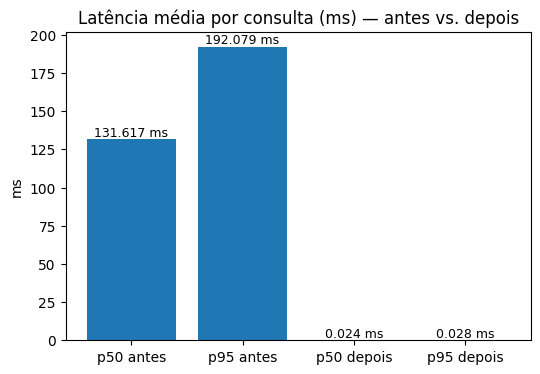

Manutenção executada: PRAGMA optimize + ANALYZE.


In [ ]:
# ==============================================
# VISUALIZAÇÃO + HOUSEKEEPING
# Sem definir cores (padrão matplotlib); rótulos em ms
# PRAGMA optimize / ANALYZE = saúde do CBO (Cost-Based Optimizer)
# ==============================================
import matplotlib.pyplot as plt

vals   = [baseline_p50, baseline_p95, after_p50, after_p95]
labels = ['p50 antes', 'p95 antes', 'p50 depois', 'p95 depois']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, vals)
plt.title('Latência média por consulta (ms) — antes vs. depois')
plt.ylabel('ms')
for b,v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v, f'{v:.3f} ms', ha='center', va='bottom', fontsize=9)
plt.show()

cur.execute("PRAGMA optimize;")
cur.execute("ANALYZE;")
conn.commit()
print("Manutenção executada: PRAGMA optimize + ANALYZE.")